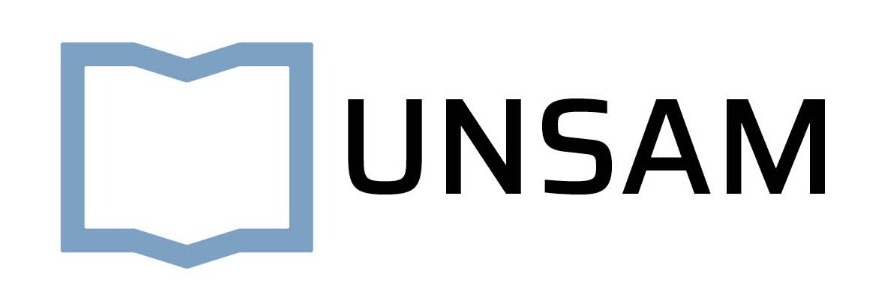

# APS : TS1 Castiñeira 

## Autor: Santiago Castiñeira

## Ejercicio 1

Utilizando en todos los casos un total de:

$$
N = 1000 \text{ muestras}
$$

se deben sintetizar y analizar las siguientes señales:

1. **Señal sinusoidal de 2 kHz**, utilizando una frecuencia de muestreo que permita obtener al menos **10 muestras por período**.

2. **Señal sinusoidal de 2 kHz**, con una potencia media de **2 W** y un desfase de:

$$
\phi = \frac{\pi}{2}
$$

3. **Ruido con distribución normal**, con las siguientes características:

$$
\mu = 0 \text{ V}
$$

$$
\sigma^2 = 0.1 \text{ W}
$$

4. **Ruido con distribución uniforme**, también con:

$$
\mu = 0 \text{ V}
$$

$$
\sigma^2 = 0.1 \text{ W}
$$

5. **Señal rectangular** de la misma frecuencia ($2\,\text{kHz}$), con una potencia media de **1 W** y un ciclo de actividad del **50 %**.

Para generar la señal rectangular se utilizarán las funciones disponibles en `scipy.signal`.

### Análisis en frecuencia

Para cada una de las señales generadas se deberá calcular y representar el **módulo de su Transformada de Fourier**.

## intruduccion ejer 1
En este ejercicio se trabajan varios de los conceptos vistos en clase sobre señales discretas y su análisis.

A partir de una determinada frecuencia de muestreo se generan distintas señales, como senoidales, ruido y una señal rectangular, teniendo en cuenta parámetros como frecuencia, amplitud, fase, potencia, media y varianza.

Luego se utiliza la Transformada Discreta de Fourier, calculada mediante la FFT, para observar cómo se distribuye el contenido de cada señal en frecuencia y comparar las diferencias entre señales periódicas y aleatorias.

### 1° parte.

Para generar la señal de $2\,\text{kHz}$ se eligió una frecuencia de muestreo de $20\,\text{kHz}$. Con esta elección se obtienen exactamente 10 muestras por cada período de la señal:

$$
\frac{f_s}{f_0} = \frac{20000}{2000} = 10
$$

Además, esta frecuencia de muestreo cumple con el criterio de Nyquist. Sin embargo, en este caso la condición de tener al menos 10 muestras por período resulta más exigente y es la que determina el valor de $f_s$.

El período de la señal es:

$$
T_0 = \frac{1}{f_0} = \frac{1}{2000} = 0.0005\,\text{s}
$$

Mientras que el período de muestreo resulta:

$$
T_s = \frac{1}{f_s} = \frac{1}{20000} = 0.00005\,\text{s}
$$

Al relacionar ambos períodos se obtiene:

$$
\frac{T_0}{T_s} = \frac{0.0005}{0.00005} = 10
$$

Por lo tanto, se tienen **10 muestras por período**, cumpliendo con la condición solicitada.

La señal a sintetizar es una senoide de $2\,\text{kHz}$. Como el enunciado no especifica la amplitud, el valor medio ni la fase inicial para este primer caso, se adoptaron los siguientes valores:

$$
v_{\max}=1\,\text{V}
$$

$$
dc=0\,\text{V}
$$

$$
\phi=0\,\text{rad}
$$

Con estos parámetros, la señal queda centrada en cero y comienza en el origen.

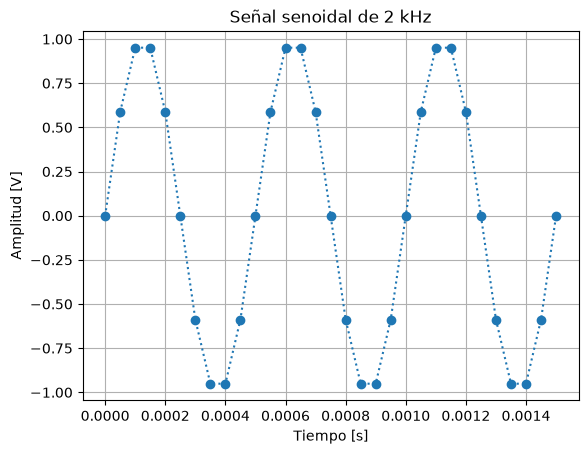

In [7]:

import numpy as np

import matplotlib.pyplot as plt
# Variables definidas
fs = 20000   # Hz (fs=20000 relacion con f0 y los 10 periodos muy por arriba de NYQ)
n = 1000     # muestras
f0 = 2000    # Hz
vmax = 1         # V Punto 1 Vmax=1 punto 2 Vmax=2 
dc = 0           # V
ph = 0          # rad punto 1 PH=0, punto 2 PH= pi/2
to= 1/f0       # periodo señal
ts = 1/fs       # periodo muestra 


#Función Seno

def mi_funcion_sen(vmax, dc, f0,n, fs, ph=ph):
    tt=np.linspace(0, (n-1)*ts,n)
    xx=dc+vmax*np.sin(2*np.pi*f0*tt+ph)
    
    return tt,xx

tt, xx = mi_funcion_sen(vmax, dc, f0, n, fs, ph)

plt.figure()
plt.plot(tt[:31], xx[:31], ':o') # frafico menos muestras para poder ver los 10 puntos por periodo
plt.title('Señal senoidal de 2 kHz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)


Con las 1000 muestras y una frecuencia de muestreo de $20\,\text{kHz}$ se observa un intervalo total de $0.05\,\text{s}$.

$$
T_{\text{total}} = \frac{N}{f_s} = \frac{1000}{20000} = 0.05\,\text{s}
$$


Como el período de la senoide es de $0.0005\,\text{s}$, en ese intervalo se tienen 100 períodos completos.
$$
T_0 = 0.0005\,\text{s}
$$

$$
\frac{0.05}{0.0005} = 100
$$

Para poder verla mejor, represento una parte de la señal.



Luego de generar la señal en el dominio temporal, se calcula su Transformada Discreta de Fourier mediante la FFT para observar su contenido en frecuencia.

Como la señal sintetizada es una senoide de $2\,\text{kHz}$, se espera encontrar una componente espectral asociada a esa frecuencia.

Con $N = 1000$ y $f_s = 20\,\text{kHz}$, la resolución en frecuencia es de $20\,\text{Hz}$.

Por lo tanto, la componente de $2\,\text{kHz}$ corresponde al índice:

$$
k = 100
$$

de la DFT.

Al tratarse de una señal real, en el espectro bilateral aparecen dos componentes simétricas correspondientes a $+2\,\text{kHz}$ y $-2\,\text{kHz}$.

Esto es propio de la representación de Fourier de una señal sinusoidal real.

Al utilizar un espectro bilateral, la componente de la senoide aparece repartida entre las frecuencias positiva y negativa.

Para una senoide de amplitud 1, al normalizar la FFT por $N$, se esperan dos picos de módulo aproximado:

$$
0.5
$$

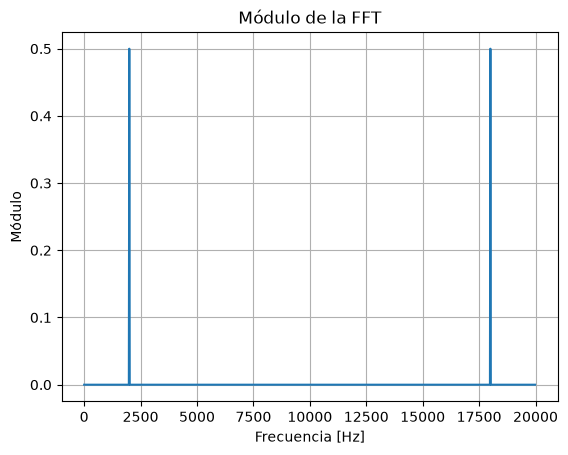

In [16]:
import numpy as np

import matplotlib.pyplot as plt
# Variables definidas
fs = 20000   # Hz (fs=20000 relacion con f0 y los 10 periodos muy por arriba de NYQ)
n = 1000     # muestras
f0 = 2000    # Hz
vmax = 1         # V Punto 1 Vmax=1 punto 2 Vmax=2 
dc = 0           # V
ph = 0          # rad punto 1 PH=0, punto 2 PH= pi/2
to= 1/f0       # periodo señal
ts = 1/fs       # periodo muestra 


#Función Seno

def mi_funcion_sen(vmax, dc, f0,n, fs, ph=ph):
    tt=np.linspace(0, (n-1)*ts,n)
    xx=dc+vmax*np.sin(2*np.pi*f0*tt+ph)
    
    return tt,xx

tt, xx = mi_funcion_sen(vmax, dc, f0, n, fs, ph)
#%% Transformada de Fourier

X = np.fft.fft(xx) / n
mod = np.abs(X)

ff = np.arange(n) * fs / n

plt.figure()
plt.plot(ff, mod)

plt.title('Módulo de la FFT')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo')
plt.grid(True)

En el módulo de la FFT se observan dos picos asociados a la frecuencia de la senoide.

Uno aparece en $2\,\text{kHz}$ y el otro corresponde a la componente de frecuencia negativa.

Como se utilizó un espectro bilateral y la señal tiene amplitud 1, cada componente presenta un módulo aproximado de $0.5$.

### Parte 2: potencia media 2W y fase= pi/2

Para obtener una potencia media de $2\,\text{W}$ se calculó la amplitud de la senoide a partir de:

$$
P = \frac{A^2}{2}
$$

De esta relación se obtiene una amplitud:

$$
A = 2
$$

Además, se agregó un desfase de:

$$
\phi = \frac{\pi}{2}
$$

Este desplazamiento no modifica la frecuencia ni la amplitud de la señal, pero sí cambia su posición dentro del ciclo.

En este caso, la senoide comienza en su valor máximo, por lo que resulta equivalente a una señal cosenoidal.
    

En la transformada se esperan las mismas componentes en frecuencia que en el caso anterior, ya que la frecuencia de la señal continúa siendo $2\,\text{kHz}$.

Al duplicarse la amplitud, el módulo de cada componente también aumenta.

El desfase de:

$$
\phi = \frac{\pi}{2}
$$

modifica la fase de la transformada, pero no su módulo.

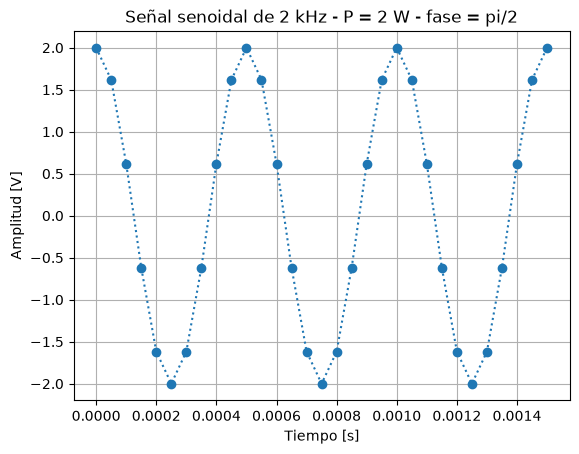

In [17]:
#%% Señal senoidal de 2 W y desfase pi/2

vmax2 = 2
ph2 = np.pi/2

tt2, xx2 = mi_funcion_sen(vmax2, dc, f0, n, fs, ph2)

plt.figure()
plt.plot(tt2[:31], xx2[:31], ':o')

plt.title('Señal senoidal de 2 kHz - P = 2 W - fase = pi/2')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)

La nueva señal mantiene la frecuencia de $2\,\text{kHz}$, pero su amplitud aumenta a 2 para obtener una potencia media de $2\,\text{W}$.

Además, al aplicar un desfase de:

$$
\phi = \frac{\pi}{2}
$$

la señal comienza en su valor máximo.

In [18]:
#%% Verificación de potencia

P2 = np.mean(xx2**2)

print('Potencia media:', P2, 'W')

Potencia media: 1.9999999999999991 W


Con esto se verifica que el valor de la potencia media de la señal es:

$$
P = 2\,\text{W}
$$

confirmando que la amplitud elegida cumple con la condición solicitada.

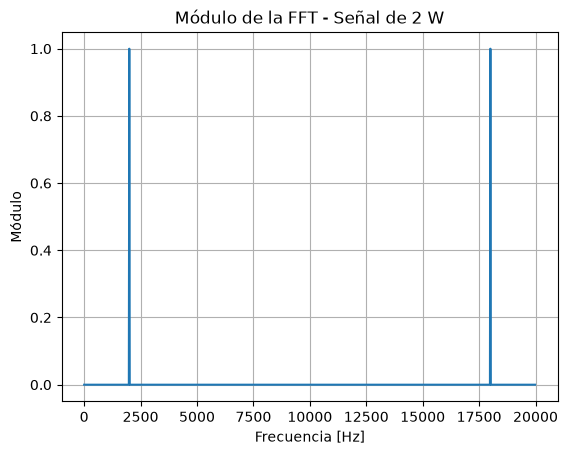

In [19]:
#%% Transformada de Fourier

X2 = np.fft.fft(xx2) / n

mod2 = np.abs(X2)

ff = np.arange(n) * fs / n

plt.figure()
plt.plot(ff, mod2)

plt.title('Módulo de la FFT - Señal de 2 W')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo')
plt.grid(True)

En el módulo de la FFT se mantienen las componentes correspondientes a la frecuencia de $2\,\text{kHz}$, ya que el desfase no modifica la frecuencia de la señal.

Al aumentar la amplitud a 2, el módulo de las componentes del espectro bilateral aumenta aproximadamente a 1.

### Parte 3: Ruido con distribución normal

Para generar el ruido normalmente distribuido se utiliza una media nula, de manera que la señal quede centrada alrededor de cero.

Como el enunciado indica una varianza de $0.1$, se calcula el desvío estándar como:

$$
\sigma = \sqrt{0.1} \approx 0.316
$$

ya que este es el parámetro utilizado para generar la distribución normal.

Como se trata de una señal aleatoria, no se espera observar una forma periódica en el dominio temporal.

Las muestras se distribuyen alrededor de cero debido a la media nula, con una dispersión determinada por la varianza de $0.1$.

Al trabajar con una cantidad finita de muestras, la media y la varianza medidas pueden diferir levemente de sus valores teóricos.

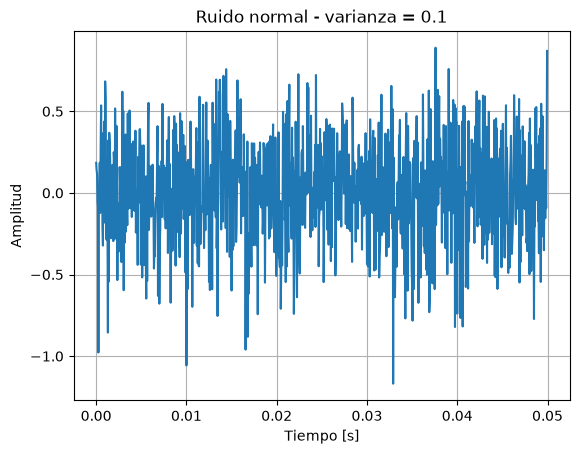

In [21]:
#%% Ruido normalmente distribuido

media = 0
varianza = 0.1
desv = np.sqrt(varianza)

ruido_normal = np.random.normal(media, desv, n)

plt.figure()
plt.plot(tt, ruido_normal)

plt.title('Ruido normal - varianza = 0.1')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)

Se generaron 1000 muestras de ruido con distribución normal, media $0$ y varianza $0.1$.

Al ser una realización aleatoria, los valores de media y varianza pueden diferir levement a los teoricos.

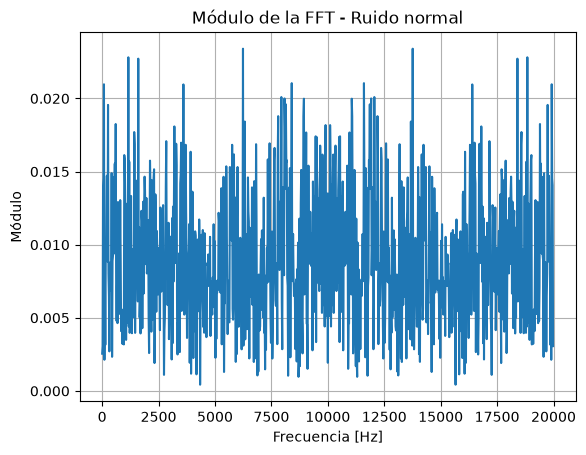

In [22]:
#%% Transformada de Fourier del ruido normal

X_ruido = np.fft.fft(ruido_normal) / n

mod_ruido = np.abs(X_ruido)

ff = np.arange(n) * fs / n

plt.figure()
plt.plot(ff, mod_ruido)

plt.title('Módulo de la FFT - Ruido normal')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo')
plt.grid(True)

En la FFT del ruido normal no aparece una frecuencia que sobresalga como pasaba con la senoide.

En cambio, el ruido se reparte entre muchas frecuencias y por eso el gráfico se ve más irregular.

### Parte 4: Ruido uniforme:

Para el ruido uniforme se eligió un intervalo simétrico alrededor de cero, de forma que su valor medio sea nulo.

A partir de la varianza pedida, $0.1$, se obtiene un límite aproximado de:

$$
a = 0.548
$$

por lo que las muestras quedan distribuidas entre $-0.548$ y $+0.548$.

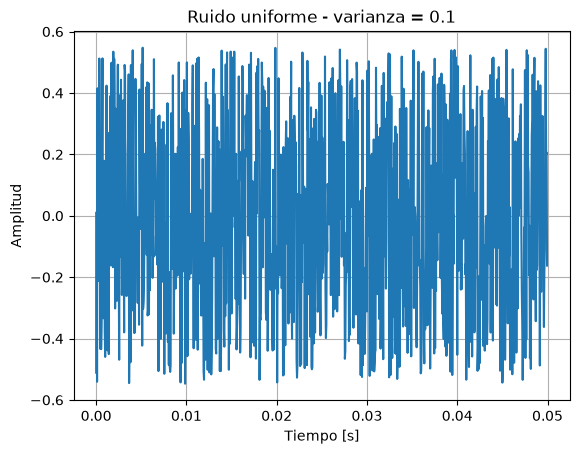

In [25]:
#%% Ruido uniformemente distribuido

varianza = 0.1
a = np.sqrt(3 * varianza)

ruido_uniforme = np.random.uniform(-a, a, n)

plt.figure()
plt.plot(tt, ruido_uniforme)

plt.title('Ruido uniforme - varianza = 0.1')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)

Se generaron 1000 muestras de ruido uniforme entre aproximadamente $-0.548$ y $+0.548$.

Como el rango está centrado en cero, la media queda cerca de $0$ y la varianza cerca de $0.1$.

Ahora hago la TFF:

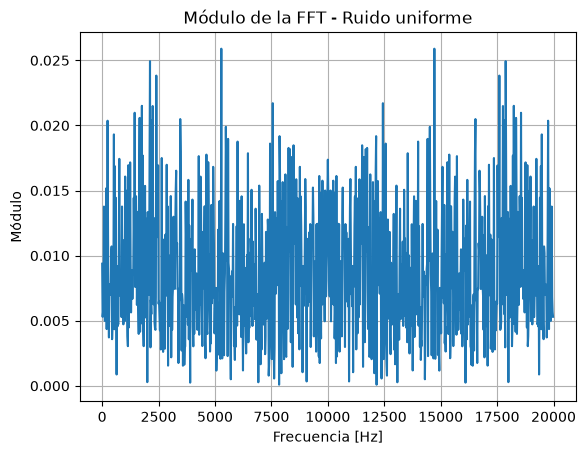

In [27]:
#%% Transformada de Fourier del ruido uniforme

X_uniforme = np.fft.fft(ruido_uniforme) / n

mod_uniforme = np.abs(X_uniforme)

ff = np.arange(n) * fs / n

plt.figure()
plt.plot(ff, mod_uniforme)

plt.title('Módulo de la FFT - Ruido uniforme')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo')
plt.grid(True)

En la FFT del ruido uniforme tampoco aparece una frecuencia que sobresalga.

La señal tiene componentes repartidas entre distintas frecuencias y el gráfico se ve irregular por el carácter aleatorio del ruido.

### Parte 5: Señal rectangular 

Para la señal rectangular se mantuvo la frecuencia de $2\,\text{kHz}$ y se utilizó un ciclo de actividad del $50\%$.

Esto significa que en cada período la señal permanece la mitad del tiempo en un nivel y la otra mitad en el nivel opuesto.

Holton define la potencia media de una señal periódica como el promedio de $|x[n]|^2$ a lo largo de un período.

En este caso, como la señal rectangular alterna entre $+1$ y $-1$, al elevar sus valores al cuadrado todas las muestras valen 1.

Por eso, el promedio también da 1 y la potencia media resulta igual a $1\,\text{W}$.

Potencia media: 1.0 W


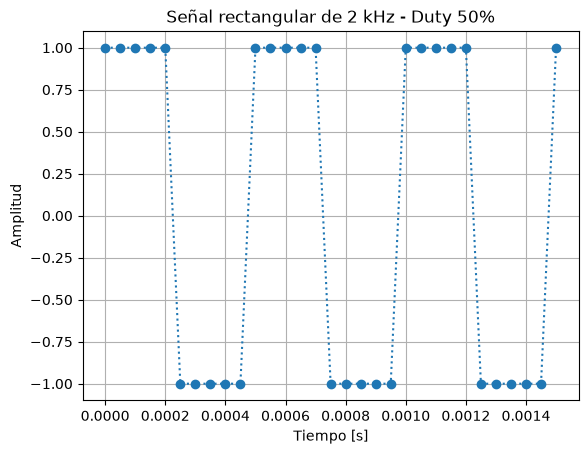

In [31]:
#%% Señal rectangular

from scipy import signal

A_rect = 1       # amplitud
duty = 0.5       # ciclo de actividad del 50 %

rectangular = A_rect * signal.square(2*np.pi*f0*tt, duty=duty)

# Graficamos solo unas muestras para verla mejor
plt.figure()
plt.plot(tt[:31], rectangular[:31], ':o') # achico las cantidad de n para ver mejor.

plt.title('Señal rectangular de 2 kHz - Duty 50%')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)

# Verificación de potencia media
P_rect = np.mean(rectangular**2)

print('Potencia media:', P_rect, 'W')

Siguiendo la definición de potencia media de Holton, se promedian los valores de la señal al cuadrado.

Como la rectangular alterna entre $+1$ y $-1$, todas las muestras al cuadrado valen 1, por lo que la potencia media resulta igual a $1\,\text{W}$.

A continuación se analiza el módulo de la FFT de la señal rectangular para observar su contenido en frecuencia.

Además de la componente fundamental de $2\,\text{kHz}$, se espera encontrar otras componentes armónicas, ya que la forma rectangular necesita varias frecuencias para poder representarse.

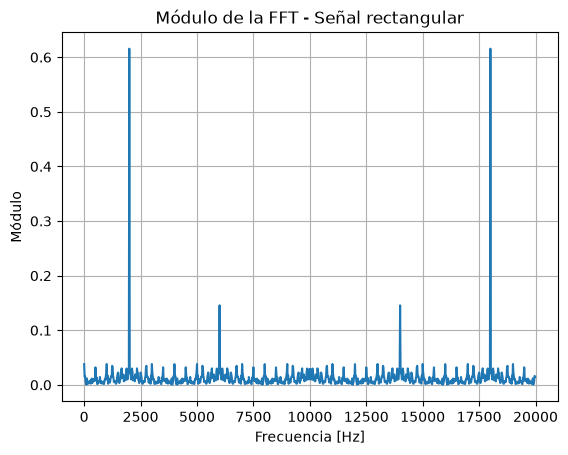

In [32]:
#%% Transformada de Fourier de la señal rectangular

X_rect = np.fft.fft(rectangular) / n

mod_rect = np.abs(X_rect)

ff = np.arange(n) * fs / n

plt.figure()
plt.plot(ff, mod_rect)

plt.title('Módulo de la FFT - Señal rectangular')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo')
plt.grid(True)

En la FFT de la señal rectangular se observa la componente principal en $2\,\text{kHz}$ y también aparecen armónicos, como el de $6\,\text{kHz}$.

A diferencia de la senoide, la señal rectangular necesita varias componentes de frecuencia para representar sus cambios bruscos entre $+1$ y $-1$.

También aparecen las componentes simétricas correspondientes a las frecuencias negativas.

### Conclusiones:
En este ejercicio se pudieron comparar distintas señales y ver que no todas se comportan igual cuando se hace la FFT.

En las señales senoidales aparece bastante claro el pico de la frecuencia que se generó, mientras que en los ruidos la información queda más repartida entre muchas frecuencias.

En la señal rectangular también aparecen varios picos debido a los armónicos.

Creo que lo más útil del ejercicio fue poder relacionar la forma que tiene una señal en el tiempo con lo que después aparece en frecuencia, además de ver cómo cambian la potencia y el espectro según los parámetros elegidos.


## Ejercicio 2:


## Ejercicio

**Hacer en lápiz y papel y subir un PDF con la resolución.**

Dado:

$$
h[n] = \delta[n] - \delta[n-4]
$$

encontrar:

$$
y[n] = x[n] * h[n]
$$

para cada una de las siguientes $x[n]$:

### a)

$$
x[n] = \cos(\omega_0 \, n \, T_S)
$$

Expresar la respuesta como un único coseno de la forma:

$$
A\cos(\omega_0 \, n \, T_S + \phi)
$$

### b)

$$
x[n] = \left(\frac{1}{2}\right)^n u[n]
$$

### c)

$$
x[n] = u[n+1] - u[n-2]
$$

In [33]:
from IPython.display import IFrame

IFrame("Ejercicio 2 TS1.pdf", width=900, height=600)